# Week 4 — Final Evaluation, Error Analysis and Recommendation Demo

In Week 4, the project is finalized.

Main tasks:

```text
1. Load baseline and deep learning results
2. Compare all models
3. Load trained Neural Collaborative Filtering model
4. Analyze prediction errors
5. Generate Top-10 recommendations for one user
6. Save final results for final report
```

The main evaluation metrics are:

```text
RMSE
MAE
```

In [1]:
import torch
print(torch.__version__)

2.11.0


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error

## 1. Set Paths

We use files created in previous weeks:

```text
Week 2: baseline results
Week 3: deep learning model and results
Week 4: final comparison, error analysis, recommendation demo
```

In [3]:
TEST_PATH = "../data/processed/test.csv"
MOVIES_PATH = "../data/movies.csv"

BASELINE_RESULTS_PATH = "../results/week2_baseline_results.csv"
DEEP_RESULTS_PATH = "../results/week3_deep_learning_results.csv"
MODEL_PATH = "../models/week3_neural_collaborative_filtering.pt"

RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Test data exists:", os.path.exists(TEST_PATH))
print("Movies data exists:", os.path.exists(MOVIES_PATH))
print("Baseline results exist:", os.path.exists(BASELINE_RESULTS_PATH))
print("Deep learning results exist:", os.path.exists(DEEP_RESULTS_PATH))
print("Trained model exists:", os.path.exists(MODEL_PATH))

Test data exists: True
Movies data exists: True
Baseline results exist: True
Deep learning results exist: True
Trained model exists: True


## 2. Load Previous Results

Here we load:

```text
baseline model results from Week 2
deep learning model results from Week 3
```

This allows us to create the final model comparison table.

In [4]:
#Load model result files

baseline_results = pd.read_csv(BASELINE_RESULTS_PATH)
deep_results = pd.read_csv(DEEP_RESULTS_PATH)

print("Baseline results:")
display(baseline_results)

print("Deep learning results:")
display(deep_results)

Baseline results:


,model,RMSE,MAE
0,Global Average Baseline,1.052172,0.841636
1,Movie Average Baseline,0.957986,0.743593
2,User Average Baseline,1.087004,0.834105
3,Combined User-Movie Average Baseline,0.948204,0.739882


Deep learning results:


,model,RMSE,MAE
0,Neural Collaborative Filtering,0.98556,0.775673


## 3. Final Model Comparison

The best model is the model with the lowest RMSE and MAE.

RMSE and MAE are used because this is a rating prediction task.

In [5]:
#Create final comparison table


final_comparison = pd.concat(
    [baseline_results, deep_results],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(by="RMSE")

final_comparison.to_csv(
    "../results/final_model_comparison.csv",
    index=False
)

final_comparison

,model,RMSE,MAE
3,Combined User-Movie Average Baseline,0.948204,0.739882
1,Movie Average Baseline,0.957986,0.743593
4,Neural Collaborative Filtering,0.985560,0.775673
0,Global Average Baseline,1.052172,0.841636
2,User Average Baseline,1.087004,0.834105


In [6]:
#Find best model


best_model = final_comparison.iloc[0]

print("Best model based on RMSE:")
print("Model:", best_model["model"])
print("RMSE:", round(best_model["RMSE"], 4))
print("MAE:", round(best_model["MAE"], 4))

Best model based on RMSE:
Model: Combined User-Movie Average Baseline
RMSE: 0.9482
MAE: 0.7399


## 4. Plot Final Model Comparison

This plot makes it easier to compare baseline models and the deep learning model.

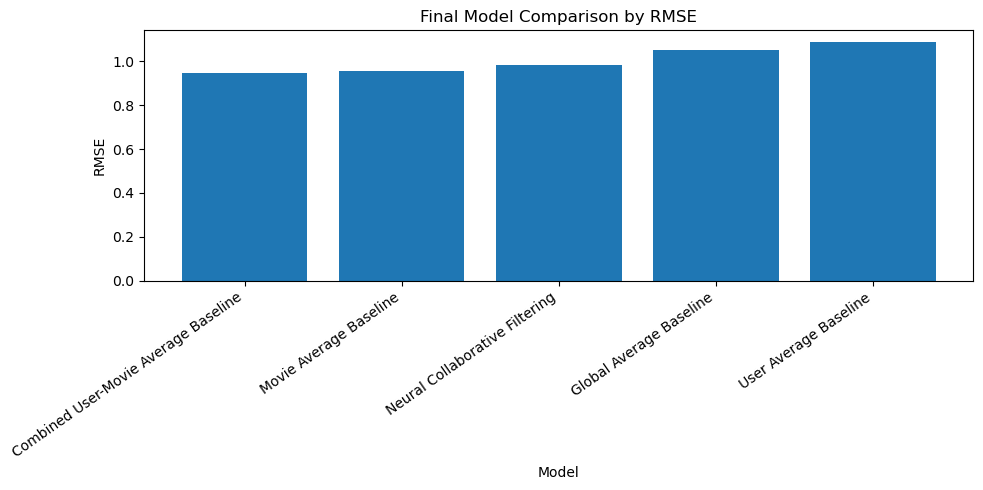

In [7]:
#Plot RMSE comparison

plt.figure(figsize=(10, 5))
plt.bar(final_comparison["model"], final_comparison["RMSE"])
plt.title("Final Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("../results/week4_final_rmse_comparison.png")
plt.show()

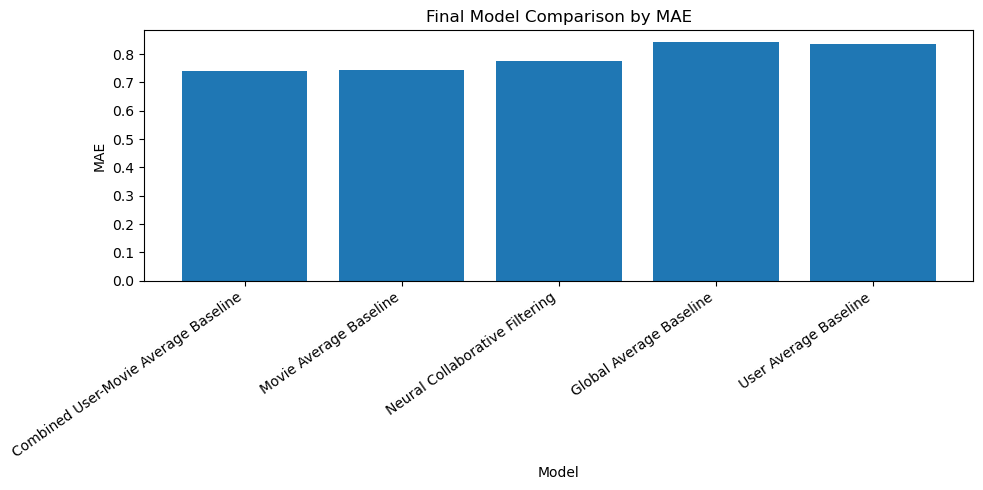

In [8]:
#Plot MAE comparison


plt.figure(figsize=(10, 5))
plt.bar(final_comparison["model"], final_comparison["MAE"])
plt.title("Final Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("../results/week4_final_mae_comparison.png")
plt.show()

## 5. Load Test Data and Movies

The test data is used for final error analysis.

The `movies.csv` file is used to show movie titles and genres.

In [9]:
#Load test data and movies

test_df = pd.read_csv(TEST_PATH)
movies = pd.read_csv(MOVIES_PATH)

print("Test shape:", test_df.shape)
print("Movies shape:", movies.shape)

test_df.head()

Test shape: (75000, 6)
Movies shape: (27278, 3)


,userId,movieId,rating,timestamp,user_index,movie_index
0,33323,89650,2.5,1402881001,25710,11689
1,14435,306,4.0,835571989,11206,298
2,128494,532,3.0,836549086,99076,519
3,24401,2805,3.0,998609986,18892,2569
4,37357,5459,2.5,1133992953,28807,5005


## 6. Rebuild Neural Collaborative Filtering Model

To use the saved model, we must define the same model architecture as in Week 3.

In [10]:
#Define model class


class NeuralCollaborativeFiltering(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim=64):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)

        self.network = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, user_ids, movie_ids):
        user_vector = self.user_embedding(user_ids)
        movie_vector = self.movie_embedding(movie_ids)

        combined_vector = torch.cat(
            [user_vector, movie_vector],
            dim=1
        )

        predicted_rating = self.network(combined_vector)

        return predicted_rating.squeeze()

In [11]:
#Select device and load trained model


if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

checkpoint = torch.load(MODEL_PATH, map_location=device)

num_users = checkpoint["num_users"]
num_movies = checkpoint["num_movies"]
embedding_dim = checkpoint["embedding_dim"]

model = NeuralCollaborativeFiltering(
    num_users=num_users,
    num_movies=num_movies,
    embedding_dim=embedding_dim
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Trained model loaded successfully.")

Device: cpu
Trained model loaded successfully.


## 7. Create Test Dataset for Prediction

To perform error analysis, we need predictions on the test set.

In [12]:
#Create Dataset and DataLoader for test data


class MovieRatingDataset(Dataset):
    def __init__(self, dataframe):
        self.users = torch.tensor(
            dataframe["user_index"].values,
            dtype=torch.long
        )
        self.movies = torch.tensor(
            dataframe["movie_index"].values,
            dtype=torch.long
        )
        self.ratings = torch.tensor(
            dataframe["rating"].values,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, index):
        return self.users[index], self.movies[index], self.ratings[index]


test_dataset = MovieRatingDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=4096,
    shuffle=False
)

print("Test batches:", len(test_loader))

Test batches: 19


## 8. Generate Predictions for Error Analysis

Predicted ratings are clipped to the valid MovieLens range:

```text
0.5 to 5.0
```

In [13]:
#Predict ratings on test set

all_predictions = []
all_targets = []

model.eval()

with torch.no_grad():
    for users, movie_ids, ratings in test_loader:
        users = users.to(device)
        movie_ids = movie_ids.to(device)
        ratings = ratings.to(device)

        predictions = model(users, movie_ids)

        predictions = predictions.detach().cpu().numpy()
        ratings = ratings.detach().cpu().numpy()

        predictions = np.clip(predictions, 0.5, 5.0)

        all_predictions.extend(predictions)
        all_targets.extend(ratings)

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
mae = mean_absolute_error(all_targets, all_predictions)

print("Final Neural Model Test Metrics")
print("===============================")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

Final Neural Model Test Metrics
RMSE: 0.9856
MAE:  0.7757


## 9. Error Analysis

Error analysis helps us understand where the model performs well and where it makes large mistakes.

We calculate:

```text
absolute_error = |real_rating - predicted_rating|
```

In [14]:
#Create error analysis table


error_df = test_df.copy()

error_df["predicted_rating"] = all_predictions
error_df["absolute_error"] = np.abs(
    error_df["rating"] - error_df["predicted_rating"]
)

error_df = error_df.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

error_df = error_df[
    [
        "userId",
        "movieId",
        "title",
        "genres",
        "rating",
        "predicted_rating",
        "absolute_error"
    ]
]

error_df.head()

,userId,movieId,title,genres,rating,predicted_rating,absolute_error
0,33323,89650,Ironclad (2011),Action|Adventure,2.5,2.975355,0.475355
1,14435,306,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama,4.0,3.575771,0.424229
2,128494,532,Serial Mom (1994),Comedy|Crime|Horror,3.0,3.243299,0.243299
3,24401,2805,Mickey Blue Eyes (1999),Comedy|Romance,3.0,3.342780,0.342780
4,37357,5459,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...,Action|Comedy|Sci-Fi,2.5,2.556062,0.056062


In [15]:
best_predictions = error_df.sort_values(
    by="absolute_error",
    ascending=True
).head(10)

best_predictions

,userId,movieId,title,genres,rating,predicted_rating,absolute_error
68364,71592,6944,Father of the Bride (1991),Comedy,3.5,3.500005,0.000005
63168,74654,2150,"Gods Must Be Crazy, The (1980)",Adventure|Comedy,3.0,3.000030,0.000030
25712,31659,540,Sliver (1993),Thriller,3.0,3.000052,0.000052
67172,51526,1432,Metro (1997),Action|Comedy|Crime|Drama|Thriller,3.0,3.000063,0.000063
66353,76085,3717,Gone in 60 Seconds (2000),Action|Crime,3.0,2.999923,0.000077
45680,64537,3178,"Hurricane, The (1999)",Drama,4.0,3.999900,0.000100
47006,45977,6350,Laputa: Castle in the Sky (Tenkû no shiro Rapy...,Action|Adventure|Animation|Children|Fantasy|Sc...,4.0,3.999898,0.000102
34073,64901,1438,Dante's Peak (1997),Action|Thriller,3.0,2.999892,0.000108
16636,60522,26662,Kiki's Delivery Service (Majo no takkyûbin) (1...,Adventure|Animation|Children|Drama|Fantasy,3.5,3.499884,0.000116
12640,8258,428,"Bronx Tale, A (1993)",Drama,3.5,3.500118,0.000118


In [16]:
worst_predictions = error_df.sort_values(
    by="absolute_error",
    ascending=False
).head(10)

worst_predictions

,userId,movieId,title,genres,rating,predicted_rating,absolute_error
71527,24443,527,Schindler's List (1993),Drama|War,0.5,4.537297,4.037297
69221,121410,1203,12 Angry Men (1957),Drama,0.5,4.378030,3.878030
18743,49213,527,Schindler's List (1993),Drama|War,0.5,4.376951,3.876951
14615,78428,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.5,4.343060,3.843060
64592,116603,356,Forrest Gump (1994),Comedy|Drama|Romance|War,0.5,4.291595,3.791595
68317,107478,1198,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,0.5,4.288787,3.788787
14504,11073,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,0.5,4.287101,3.787101
37975,17686,1193,One Flew Over the Cuckoo's Nest (1975),Drama,0.5,4.271918,3.771918
38557,5708,913,"Maltese Falcon, The (1941)",Film-Noir|Mystery,0.5,4.266294,3.766294
67524,115861,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,0.5,4.255976,3.755976


In [17]:
error_df.to_csv(
    "../results/week4_error_analysis.csv",
    index=False
)

best_predictions.to_csv(
    "../results/week4_best_predictions.csv",
    index=False
)

worst_predictions.to_csv(
    "../results/week4_worst_predictions.csv",
    index=False
)

print("Error analysis files saved:")
print("../results/week4_error_analysis.csv")
print("../results/week4_best_predictions.csv")
print("../results/week4_worst_predictions.csv")

Error analysis files saved:
../results/week4_error_analysis.csv
../results/week4_best_predictions.csv
../results/week4_worst_predictions.csv


## 10. Top-10 Recommendation Demo

Here we create a simple recommendation example for one user.

Steps:

```text
1. Select one user
2. Find movies the user has not rated
3. Predict ratings for candidate movies
4. Sort movies by predicted rating
5. Recommend Top-10 movies
```

In [18]:
#Prepare recommendation demo

example_user_id = test_df["userId"].iloc[0]
example_user_index = test_df[test_df["userId"] == example_user_id]["user_index"].iloc[0]

rated_movie_ids = test_df[test_df["userId"] == example_user_id]["movieId"].unique()

candidate_movies = movies[
    ~movies["movieId"].isin(rated_movie_ids)
].copy()

movie_index_mapping = test_df[["movieId", "movie_index"]].drop_duplicates()

candidate_movies = candidate_movies.merge(
    movie_index_mapping,
    on="movieId",
    how="inner"
)

candidate_movies = candidate_movies.sample(
    n=min(1000, len(candidate_movies)),
    random_state=42
)

print("Example userId:", example_user_id)
print("Candidate movies:", candidate_movies.shape)

Example userId: 33323
Candidate movies: (1000, 4)


In [19]:
#Predict ratings for candidate movies
candidate_user_tensor = torch.tensor(
    [example_user_index] * len(candidate_movies),
    dtype=torch.long
).to(device)

candidate_movie_tensor = torch.tensor(
    candidate_movies["movie_index"].values,
    dtype=torch.long
).to(device)

model.eval()

with torch.no_grad():
    candidate_predictions = model(
        candidate_user_tensor,
        candidate_movie_tensor
    ).detach().cpu().numpy()

candidate_predictions = np.clip(candidate_predictions, 0.5, 5.0)

candidate_movies["predicted_rating"] = candidate_predictions

top10_recommendations = candidate_movies.sort_values(
    by="predicted_rating",
    ascending=False
).head(10)

top10_recommendations[
    ["movieId", "title", "genres", "predicted_rating"]
]

,movieId,title,genres,predicted_rating
6263,55253,"Lust, Caution (Se, jie) (2007)",Drama|Romance|Thriller|War,4.152637
6603,65642,"Timecrimes (Cronocrímenes, Los) (2007)",Sci-Fi|Thriller,4.117789
4105,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,4.115857
742,951,His Girl Friday (1940),Comedy|Romance,4.031986
1018,1304,Butch Cassidy and the Sundance Kid (1969),Action|Western,3.982644
1017,1303,"Man Who Would Be King, The (1975)",Adventure|Drama,3.968776
965,1250,"Bridge on the River Kwai, The (1957)",Adventure|Drama|War,3.954130
457,527,Schindler's List (1993),Drama|War,3.941506
5670,33794,Batman Begins (2005),Action|Crime|IMAX,3.924328
4126,5995,"Pianist, The (2002)",Drama|War,3.870218


In [20]:
top10_recommendations[
    ["movieId", "title", "genres", "predicted_rating"]
].to_csv(
    "../results/week4_top10_recommendations.csv",
    index=False
)

print("Top-10 recommendations saved:")
print("../results/week4_top10_recommendations.csv")

Top-10 recommendations saved:
../results/week4_top10_recommendations.csv


## 11. Final Summary

The final summary file will be used in the final report.

In [21]:
summary_path = "../results/week4_final_summary.txt"

with open(summary_path, "w", encoding="utf-8") as file:
    file.write("Week 4 Final Evaluation Summary\n")
    file.write("=" * 40 + "\n\n")

    file.write("Best model based on RMSE:\n")
    file.write(f"{best_model['model']}\n")
    file.write(f"RMSE: {best_model['RMSE']:.4f}\n")
    file.write(f"MAE: {best_model['MAE']:.4f}\n\n")

    file.write("Neural Collaborative Filtering final test results:\n")
    file.write(f"RMSE: {rmse:.4f}\n")
    file.write(f"MAE: {mae:.4f}\n\n")

    file.write("Created output files:\n")
    file.write("- final_model_comparison.csv\n")
    file.write("- week4_error_analysis.csv\n")
    file.write("- week4_best_predictions.csv\n")
    file.write("- week4_worst_predictions.csv\n")
    file.write("- week4_top10_recommendations.csv\n")

print("Final summary saved:")
print(summary_path)

Final summary saved:
../results/week4_final_summary.txt


In [22]:
print("Week 4 completed successfully.")

print("\nCreated files:")
print("../results/final_model_comparison.csv")
print("../results/week4_final_rmse_comparison.png")
print("../results/week4_final_mae_comparison.png")
print("../results/week4_error_analysis.csv")
print("../results/week4_best_predictions.csv")
print("../results/week4_worst_predictions.csv")
print("../results/week4_top10_recommendations.csv")
print("../results/week4_final_summary.txt")

Week 4 completed successfully.

Created files:
../results/final_model_comparison.csv
../results/week4_final_rmse_comparison.png
../results/week4_final_mae_comparison.png
../results/week4_error_analysis.csv
../results/week4_best_predictions.csv
../results/week4_worst_predictions.csv
../results/week4_top10_recommendations.csv
../results/week4_final_summary.txt
